In [1]:
import pandas as pd
input_file = 'oracle_data_kb_elevations newww.csv'
df_row = pd.read_csv(input_file, header= 0)
print(f"Data successfully saved to Data Frame")

Data successfully saved to Data Frame


In [2]:
# Remove rows where 'STATE_NAME' is 'AK'
df_row = df_row[df_row['STATE_NAME'] != 'AK']

print("DataFrame after removing rows where STATE_NAME is AK:")
print(df_row.head())
print("\nRemaining rows:", len(df_row))

DataFrame after removing rows where STATE_NAME is AK:
      BORE_ID  HEADER_ID STATE_NAME COUNTY_NAME WELL_PROFILE_CODE  \
2204  5532762    5446573         AL        BIBB                 V   
2205  5532771    5446580         AL        BIBB                 V   
2206  5532775    5446586         AL        BIBB                 V   
2207  5532829    5446641         AL        BIBB                 V   
2208  5532836    5446647         AL        BIBB                 V   

      FIRST_ELEVATION FIRST_ELEVATION_TYPE_CODE FIRST_ELEVATION_SOURCE  \
2204            453.0                        KB              ST_ALSOGB   
2205            510.0                        KB              ST_ALSOGB   
2206            571.0                        KB              ST_ALSOGB   
2207            366.0                        KB                  STATE   
2208            370.0                        KB                  STATE   

      SECOND_ELEVATION SECOND_ELEVATION_TYPE_CODE SECOND_ELEVATION_SOURCE  \
2204     

In [3]:
# Remove rows where 'GROUND_ELEVATION_TYPE' is 'GR' and 'GROUND_ELEVATION' is 0
df_row = df_row[~((df_row['GROUND_ELEVATION_TYPE'] == 'GR') & (df_row['GROUND_ELEVATION'] == 0))]
# Remove rows where 'KB HEIGHT' > 50 or 'KB HEIGHT' < 0
df_row = df_row[~((df_row['KB HEIGHT'] > 50) | (df_row['KB HEIGHT'] < 0))]
# Remove rows where 'GROUND_ELEVATION_TYPE' is 'EG' and 'GROUND_ELEVATION' is 0
df_row = df_row[~((df_row['GROUND_ELEVATION_TYPE'] == 'EG') & (df_row['GROUND_ELEVATION'] == 0))]

print("DataFrame after removing rows where GROUND_ELEVATION_TYPE is GR , EG and GROUND_ELEVATION is 0: and KB Hight > 50 or KB Hight < 0")
print(df_row.head())
print("\nRemaining rows:", len(df_row))

DataFrame after removing rows where GROUND_ELEVATION_TYPE is GR , EG and GROUND_ELEVATION is 0: and KB Hight > 50 or KB Hight < 0
      BORE_ID  HEADER_ID STATE_NAME COUNTY_NAME WELL_PROFILE_CODE  \
2204  5532762    5446573         AL        BIBB                 V   
2205  5532771    5446580         AL        BIBB                 V   
2206  5532775    5446586         AL        BIBB                 V   
2207  5532829    5446641         AL        BIBB                 V   
2208  5532836    5446647         AL        BIBB                 V   

      FIRST_ELEVATION FIRST_ELEVATION_TYPE_CODE FIRST_ELEVATION_SOURCE  \
2204            453.0                        KB              ST_ALSOGB   
2205            510.0                        KB              ST_ALSOGB   
2206            571.0                        KB              ST_ALSOGB   
2207            366.0                        KB                  STATE   
2208            370.0                        KB                  STATE   

      SECO

In [5]:
missing_values = df_row.isnull().sum()
missing_percentage = (missing_values / len(df_row)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print("Missing values information:")
print(missing_info)

Missing values information:
                            Missing Values  Percentage
BORE_ID                                  0    0.000000
HEADER_ID                                0    0.000000
STATE_NAME                               0    0.000000
COUNTY_NAME                              0    0.000000
WELL_PROFILE_CODE                        0    0.000000
FIRST_ELEVATION                          0    0.000000
FIRST_ELEVATION_TYPE_CODE                0    0.000000
FIRST_ELEVATION_SOURCE                   4    0.000883
SECOND_ELEVATION                    327607   72.301869
SECOND_ELEVATION_TYPE_CODE          327559   72.291276
SECOND_ELEVATION_SOURCE             327619   72.304518
GROUND_ELEVATION                         0    0.000000
GROUND_ELEVATION_SOURCE                  0    0.000000
GROUND_ELEVATION_TYPE                    0    0.000000
KB HEIGHT                                0    0.000000
WELL_DATE                                0    0.000000
LATITUDE                             

In [6]:
#df = df_row.drop(columns=['STATE_NAME','COUNTY_NAME','FIRST_ELEVATION_SOURCE','GROUND_ELEVATION_SOURCE','SECOND_ELEVATION_SOURCE','SECOND_ELEVATION', 'SECOND_ELEVATION_TYPE_CODE', 'SECOND_ELEVATION_SOURCE','BORE_ID','HEADER_ID'])
df = df_row.drop(columns=['COUNTY_NAME','FIRST_ELEVATION_SOURCE','GROUND_ELEVATION_SOURCE','SECOND_ELEVATION_SOURCE','SECOND_ELEVATION', 'SECOND_ELEVATION_TYPE_CODE', 'SECOND_ELEVATION_SOURCE','BORE_ID','HEADER_ID'])

#df = df.dropna(subset=['FIRST_ELEVATION_SOURCE'])

print("DataFrame after handling missing values:")
print(df.isnull().sum())

DataFrame after handling missing values:
STATE_NAME                   0
WELL_PROFILE_CODE            0
FIRST_ELEVATION              0
FIRST_ELEVATION_TYPE_CODE    0
GROUND_ELEVATION             0
GROUND_ELEVATION_TYPE        0
KB HEIGHT                    0
WELL_DATE                    0
LATITUDE                     0
LONGITUDE                    0
dtype: int64


In [213]:
import pandas as pd
from datetime import date

# Get today's date
today = date.today()

# Ensure WELL_DATE column is treated as string first
df['WELL_DATE'] = df['WELL_DATE'].astype(str).str.strip()

# Convert WELL_DATE to datetime (keeping only date part)
df['WELL_DATE'] = pd.to_datetime(df['WELL_DATE'], errors='coerce').dt.date

# Remove null values after conversion
df = df[df['WELL_DATE'].notnull()]

# Calculate WELL_AGE_YEARS
df['WELL_AGE'] = round((pd.to_datetime(today) - pd.to_datetime(df['WELL_DATE'])).dt.days / 365,2)

# Drop the original 'WELL_DATE' column
df = df.drop(columns=['WELL_DATE'])

# Display the first few rows with the new 'WELL_AGE' column
print(df[['WELL_AGE']].head())

      WELL_AGE
2204     35.58
2205     35.52
2206     35.51
2207     35.34
2208     35.35


In [202]:
print(df.head())

     STATE_NAME COUNTY_NAME WELL_PROFILE_CODE  FIRST_ELEVATION  \
2204         AL        BIBB                 V            453.0   
2205         AL        BIBB                 V            510.0   
2206         AL        BIBB                 V            571.0   
2207         AL        BIBB                 V            366.0   
2208         AL        BIBB                 V            370.0   

     FIRST_ELEVATION_TYPE_CODE  GROUND_ELEVATION GROUND_ELEVATION_TYPE  \
2204                        KB             447.0                    GR   
2205                        KB             504.0                    GR   
2206                        KB             565.0                    GR   
2207                        KB             360.0                    GR   
2208                        KB             364.0                    GR   

      KB HEIGHT   LATITUDE  LONGITUDE  WELL_AGE  
2204          6  33.096300 -87.006290     35.58  
2205          6  33.088490 -87.047960     35.52  
2206    

In [214]:
numerical_cols = df.select_dtypes(include=['number'])
descriptive_stats = numerical_cols.describe()
display(descriptive_stats)

,FIRST_ELEVATION,GROUND_ELEVATION,KB HEIGHT,LATITUDE,LONGITUDE,WELL_AGE
count,333232.000000,333232.000000,333232.000000,333232.000000,333232.000000,333232.000000
mean,2367.129119,2350.960510,16.174368,36.388557,-98.534712,28.710440
std,1801.558653,1801.024383,7.581819,5.351269,8.526853,19.268375
min,0.000000,-10.000000,6.000000,25.927120,-124.122201,0.550000
25%,958.000000,948.000000,10.000000,31.994062,-103.367805,12.680000
50%,2212.000000,2193.000000,14.000000,35.664864,-101.292802,21.690000
75%,3188.000000,3173.000000,22.000000,40.274586,-96.637840,42.720000
max,10294.000000,10283.000000,50.000000,48.999443,-79.451116,116.150000


In [10]:
!pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Histograms of Numerical Features:


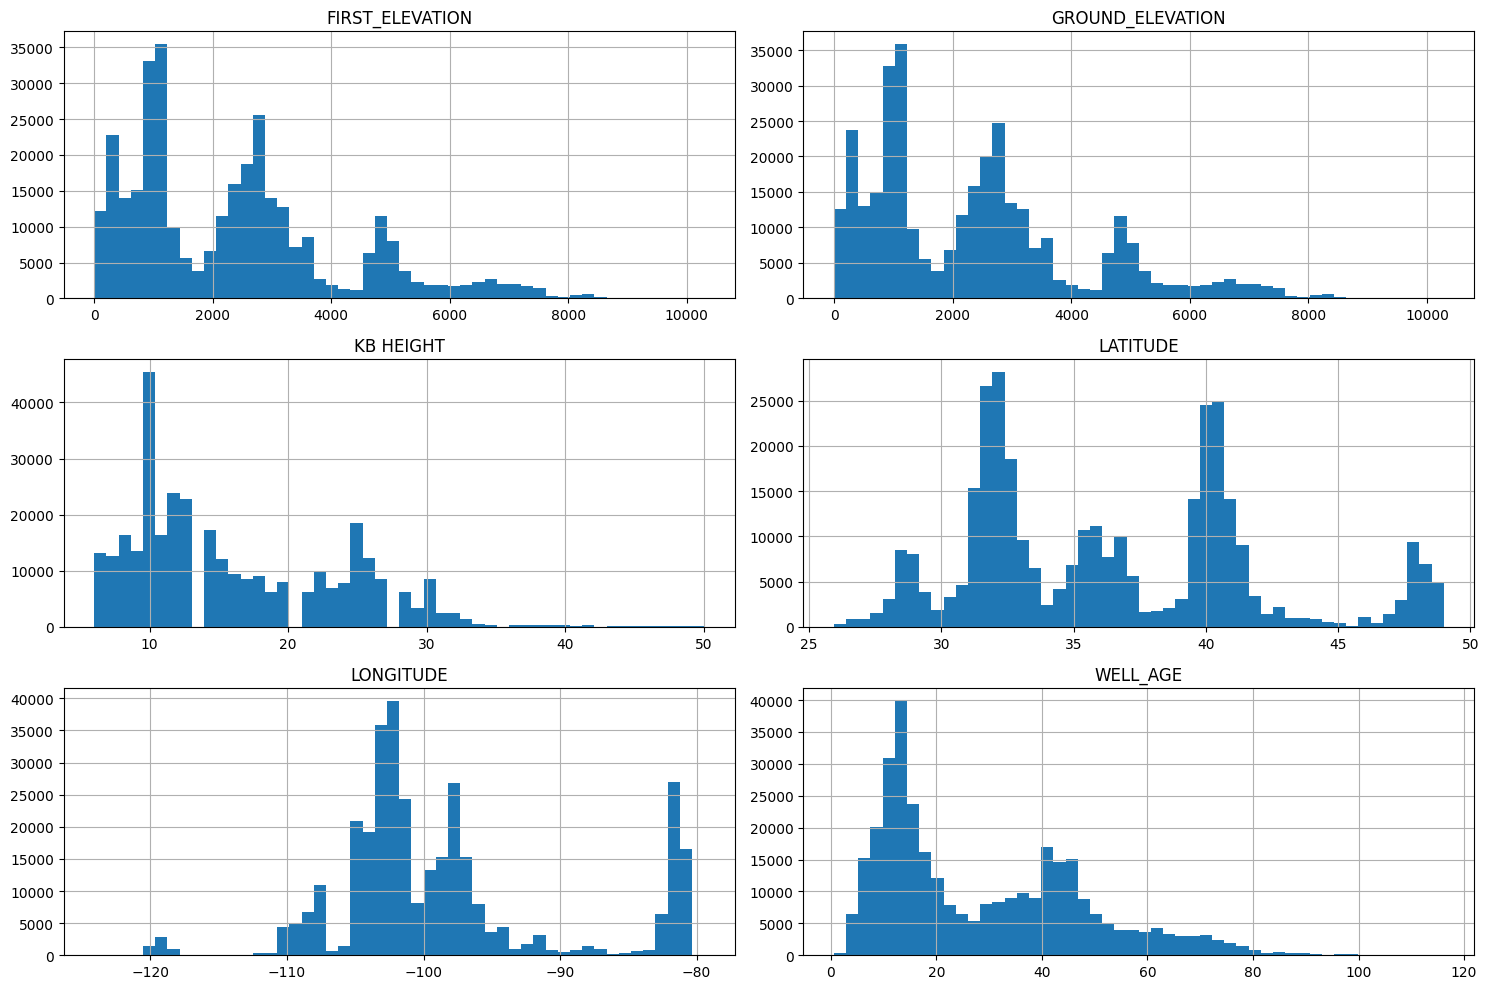

In [215]:
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['number'])

# Create histograms
print("Histograms of Numerical Features:")
numerical_cols.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()


In [216]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"Unique values for {col}: {df[col].unique()}")

Unique values for STATE_NAME: ['AL' 'AR' 'CA' 'CO' 'KS' 'KY' 'LA' 'MI' 'MO' 'MS' 'MT' 'ND' 'NM' 'NV'
 'OH' 'OK' 'TX' 'UT' 'WA' 'WV' 'WY']
Unique values for WELL_PROFILE_CODE: ['V' 'D' 'H' 'U']
Unique values for FIRST_ELEVATION_TYPE_CODE: ['KB' 'DF']
Unique values for GROUND_ELEVATION_TYPE: ['GR' 'EG' 'TS']


In [217]:
count = (df['WELL_PROFILE_CODE'] == 'U').sum()
print(f"Number of rows with WELL_PROFILE_CODE = 'U': {count}")

Number of rows with WELL_PROFILE_CODE = 'U': 265


In [218]:
#if 'U' % > 20 , remove , else keep
df = df[df['WELL_PROFILE_CODE'] != 'U'].copy()


In [219]:
import pandas as pd

# Perform one-hot encoding and drop original categorical columns
df_model = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)

print("DataFrame after one-hot encoding:")
print(df_model.head())

DataFrame after one-hot encoding:
      FIRST_ELEVATION  GROUND_ELEVATION  KB HEIGHT   LATITUDE  LONGITUDE  \
2204            453.0             447.0          6  33.096300 -87.006290   
2205            510.0             504.0          6  33.088490 -87.047960   
2206            571.0             565.0          6  33.085680 -87.041780   
2207            366.0             360.0          6  33.112772 -87.058002   
2208            370.0             364.0          6  33.105025 -87.057695   

      WELL_AGE  STATE_NAME_AL  STATE_NAME_AR  STATE_NAME_CA  STATE_NAME_CO  \
2204     35.58              1              0              0              0   
2205     35.52              1              0              0              0   
2206     35.51              1              0              0              0   
2207     35.34              1              0              0              0   
2208     35.35              1              0              0              0   

      ...  STATE_NAME_WV  STATE_NAME_WY 

In [220]:
correlations = df_model.corr()['KB HEIGHT'].sort_values(ascending=False)

correlations

KB HEIGHT                       1.000000
WELL_PROFILE_CODE_H             0.627455
STATE_NAME_TX                   0.282343
STATE_NAME_ND                   0.180469
WELL_PROFILE_CODE_D             0.093803
STATE_NAME_WY                   0.085661
FIRST_ELEVATION                 0.072311
GROUND_ELEVATION                0.068125
STATE_NAME_NM                   0.050788
GROUND_ELEVATION_TYPE_EG        0.028191
STATE_NAME_UT                   0.024260
STATE_NAME_WV                   0.018596
FIRST_ELEVATION_TYPE_CODE_KB    0.011213
STATE_NAME_AL                   0.003033
STATE_NAME_NV                   0.001866
STATE_NAME_WA                  -0.000139
STATE_NAME_MO                  -0.000239
GROUND_ELEVATION_TYPE_TS       -0.001799
STATE_NAME_MI                  -0.002872
FIRST_ELEVATION_TYPE_CODE_DF   -0.011213
STATE_NAME_MT                  -0.014658
GROUND_ELEVATION_TYPE_GR       -0.028143
STATE_NAME_KY                  -0.030931
STATE_NAME_MS                  -0.034686
STATE_NAME_CO   

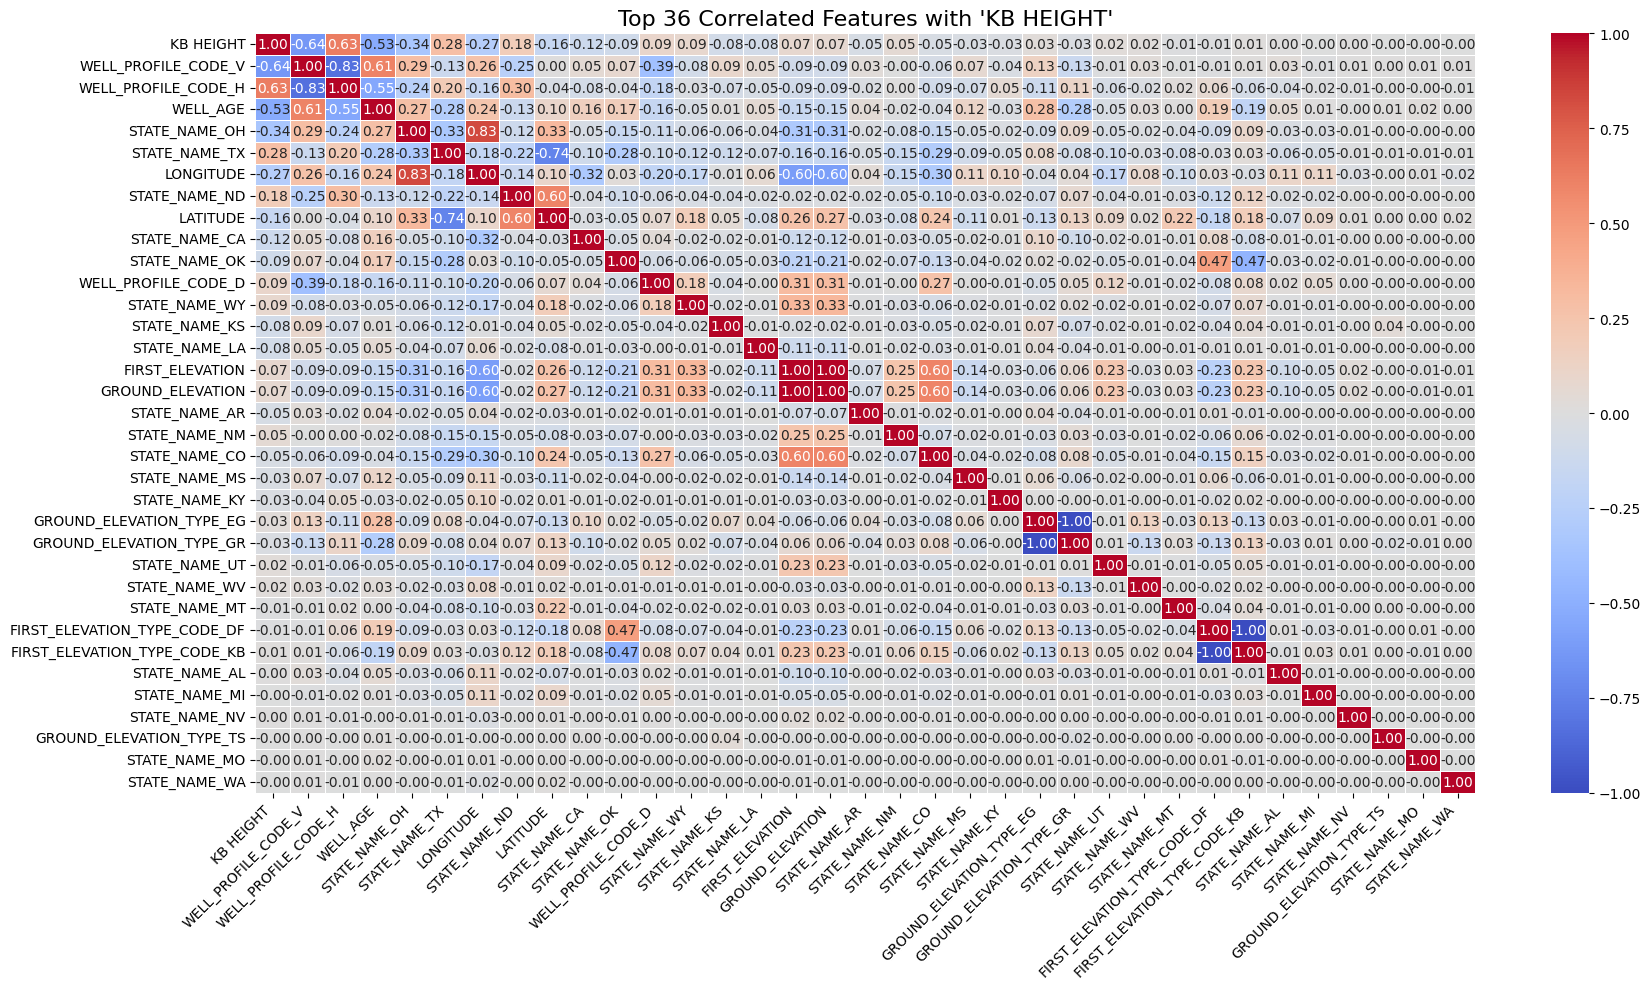

In [223]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate correlation matrix
corr_matrix = df_model.corr()

# Step 2: Get top 30 features most correlated with 'KB HEIGHT'
top_features = corr_matrix['KB HEIGHT'].abs().sort_values(ascending=False).head(36).index  # 31 to include 'KB HEIGHT' itself

# Step 3: Create a smaller correlation matrix for those features
top_corr = corr_matrix.loc[top_features, top_features]

# Step 4: Plot the heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(top_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 36 Correlated Features with 'KB HEIGHT'", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [225]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

x = df_model.drop('KB HEIGHT', axis=1)

# Standardize the data before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Apply PCA
pca = PCA(n_components=0.95)  # Keep 95% variance
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with the principal components
df_pca = pd.DataFrame(data=X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

# Add KB HEIGHT back to the PCA-transformed DataFrame
df_pca['KB HEIGHT'] = df_model['KB HEIGHT'].values

print(df_pca.head())

# Now you can use df_pca for further analysis or modeling.
# The number of columns will be less than the original, with less redundancy.

# Check how many components were selected
print(f"Number of principal components selected: {X_pca.shape[1]}")

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.115711 -0.872498  0.877046  1.022284 -0.484100  1.402531  2.377316   
1 -2.086684 -0.877595  0.862269  1.020897 -0.489572  1.403922  2.366631   
2 -2.058092 -0.885622  0.847673  1.019128 -0.495281  1.407040  2.354467   
3 -2.151434 -0.856598  0.900023  1.024474 -0.474893  1.397952  2.394661   
4 -2.149888 -0.856792  0.898697  1.024804 -0.475754  1.398144  2.393910   

        PC8       PC9      PC10  ...      PC16      PC17      PC18      PC19  \
0 -0.841465  3.679112  1.603262  ... -2.129891 -1.351575  0.318841  0.169505   
1 -0.841784  3.677676  1.601879  ... -2.129794 -1.351626  0.318786  0.169622   
2 -0.842070  3.676279  1.600168  ... -2.129705 -1.351691  0.318677  0.169772   
3 -0.841192  3.680307  1.606863  ... -2.129995 -1.351478  0.319147  0.169213   
4 -0.841230  3.680373  1.606718  ... -2.129977 -1.351481  0.319133  0.169225   

       PC20      PC21      PC22      PC23      PC24  KB HEIGHT  
0  

In [226]:
# Calculate the correlation matrix

# Get correlations with 'KB HEIGHT' and sort them in descending order
correlations = df_pca.corr()['KB HEIGHT'].sort_values(ascending=False)

correlations

KB HEIGHT    1.000000
PC2          0.574282
PC1          0.284622
PC5          0.221470
PC6          0.154892
PC3          0.139637
PC23         0.043823
PC13         0.042897
PC15         0.034336
PC21         0.029411
PC12         0.014269
PC9          0.012390
PC4          0.008270
PC20         0.003781
PC18         0.003216
PC19         0.000618
PC11        -0.000580
PC14        -0.011226
PC24        -0.014654
PC22        -0.022541
PC10        -0.023943
PC17        -0.026847
PC16        -0.071213
PC8         -0.074899
PC7         -0.085145
Name: KB HEIGHT, dtype: float64

In [31]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


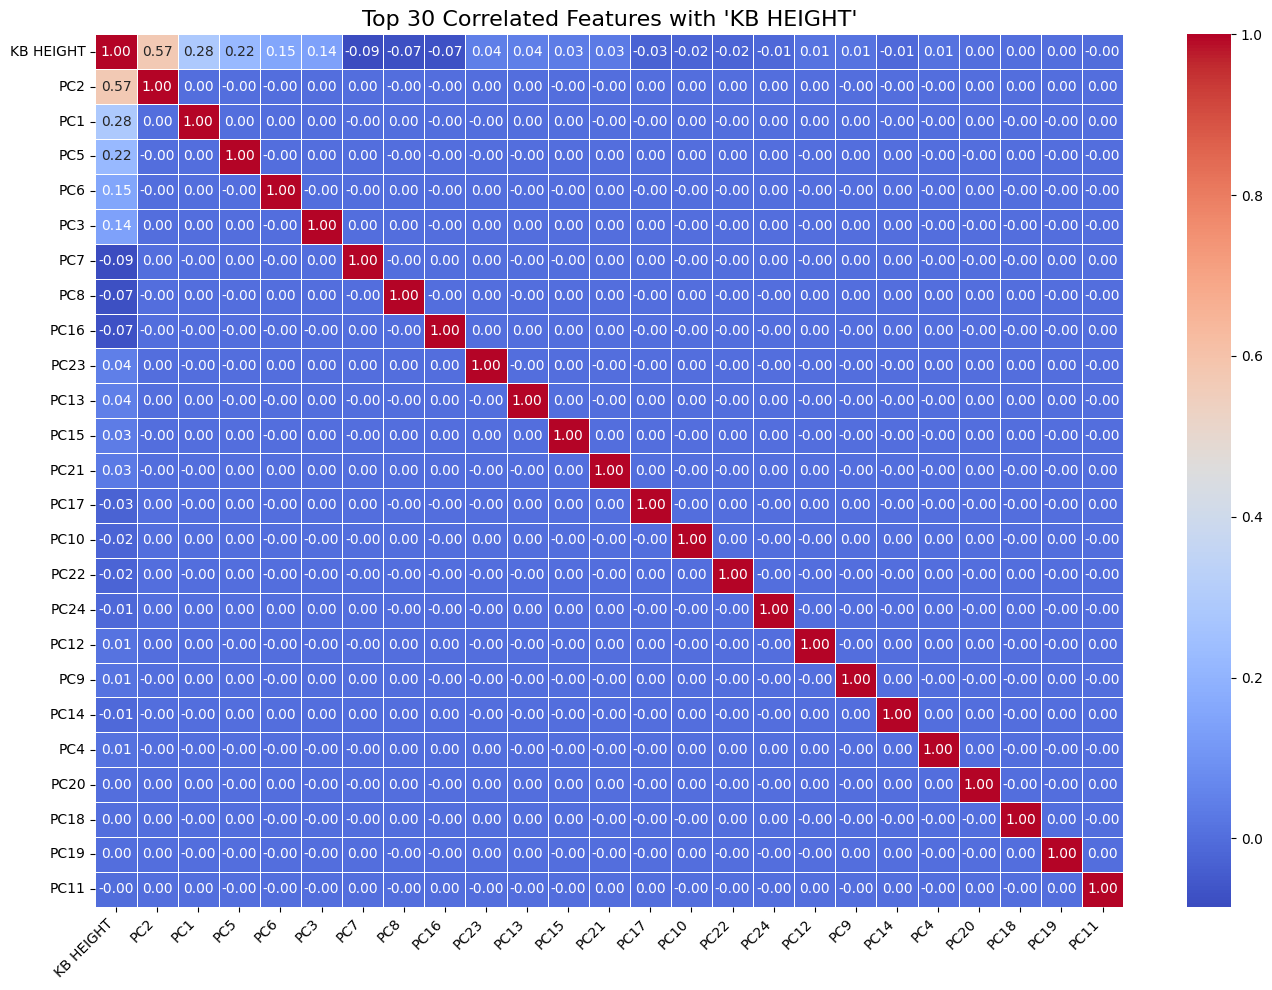

In [227]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate correlation matrix
corr_matrix = df_pca.corr()

# Step 2: Get top 30 features most correlated with 'KB HEIGHT'
top_features = corr_matrix['KB HEIGHT'].abs().sort_values(ascending=False).head(31).index  # 31 to include 'KB HEIGHT' itself

# Step 3: Create a smaller correlation matrix for those features
top_corr = corr_matrix.loc[top_features, top_features]

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(top_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 30 Correlated Features with 'KB HEIGHT'", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [33]:
!pip install statsmodels


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [228]:
df_model.head()

,FIRST_ELEVATION,GROUND_ELEVATION,KB HEIGHT,LATITUDE,LONGITUDE,WELL_AGE,STATE_NAME_AL,STATE_NAME_AR,STATE_NAME_CA,STATE_NAME_CO,...,STATE_NAME_WV,STATE_NAME_WY,WELL_PROFILE_CODE_D,WELL_PROFILE_CODE_H,WELL_PROFILE_CODE_V,FIRST_ELEVATION_TYPE_CODE_DF,FIRST_ELEVATION_TYPE_CODE_KB,GROUND_ELEVATION_TYPE_EG,GROUND_ELEVATION_TYPE_GR,GROUND_ELEVATION_TYPE_TS
2204,453.0,447.0,6,33.096300,-87.006290,35.58,1,0,0,0,...,0,0,0,0,1,0,1,0,1,0
2205,510.0,504.0,6,33.088490,-87.047960,35.52,1,0,0,0,...,0,0,0,0,1,0,1,0,1,0
2206,571.0,565.0,6,33.085680,-87.041780,35.51,1,0,0,0,...,0,0,0,0,1,0,1,0,1,0
2207,366.0,360.0,6,33.112772,-87.058002,35.34,1,0,0,0,...,0,0,0,0,1,0,1,0,1,0
2208,370.0,364.0,6,33.105025,-87.057695,35.35,1,0,0,0,...,0,0,0,0,1,0,1,0,1,0


In [236]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
# Separate features (X) and target (y)
#feature = ['WELL_PROFILE_CODE_H', 
#                'WELL_PROFILE_CODE_D',
#                'WELL_PROFILE_CODE_V',
#                'FIRST_ELEVATION',  
#                'GROUND_ELEVATION', 
#                #'GROUND_ELEVATION_TYPE_EG', 
#                #'FIRST_ELEVATION_TYPE_CODE_KB'
#                ]
selected_features = [
    # Well characteristics
    'WELL_AGE',
    'WELL_PROFILE_CODE_H',
    'WELL_PROFILE_CODE_V',
    'WELL_PROFILE_CODE_D',

    # Spatial info
    'LATITUDE',
    'LONGITUDE',

    # Elevation
    'FIRST_ELEVATION',
    'GROUND_ELEVATION',

    # Strong state indicators only
    'STATE_NAME_TX',
    'STATE_NAME_OH',
    'STATE_NAME_ND'
]

X = df_model[selected_features]
X = sm.add_constant(X)
y = df_model['KB HEIGHT']

#X = df_pca.drop('KB HEIGHT', axis=1)
#X = sm.add_constant(X)
#y = df_pca['KB HEIGHT']

# Standardize the data before applying PCA
scaler = StandardScaler()
X = scaler.fit_transform(X)

model = sm.OLS(y, X)  # y is your dependent variable, X is your independent variable (with constant)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:              KB HEIGHT   R-squared (uncentered):                   0.181
Model:                            OLS   Adj. R-squared (uncentered):              0.181
Method:                 Least Squares   F-statistic:                              7352.
Date:                Mon, 26 Jan 2026   Prob (F-statistic):                        0.00
Time:                        11:17:00   Log-Likelihood:                     -1.3991e+06
No. Observations:              332967   AIC:                                  2.798e+06
Df Residuals:                  332957   BIC:                                  2.798e+06
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\asstlk\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [237]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# -----------------------------
# Data
# -----------------------------
#feature_cols = ['WELL_PROFILE_CODE_H','WELL_PROFILE_CODE_D','FIRST_ELEVATION','GROUND_ELEVATION',            
#  'GROUND_ELEVATION_TYPE_EG','FIRST_ELEVATION_TYPE_CODE_KB','GROUND_ELEVATION_TYPE_TS',      
#'FIRST_ELEVATION_TYPE_CODE_DF','GROUND_ELEVATION_TYPE_GR' ,'LATITUDE' ,'LONGITUDE','WELL_AGE' ,'WELL_PROFILE_CODE_V']
#feature_cols = ['WELL_PROFILE_CODE_H', 
#                'WELL_PROFILE_CODE_D',
#                'WELL_PROFILE_CODE_V',
#                'FIRST_ELEVATION',  
#                'GROUND_ELEVATION', 
                #'GROUND_ELEVATION_TYPE_EG', 
                #'FIRST_ELEVATION_TYPE_CODE_KB'
#                ]

#X = df_model[feature_cols]
#y = df_model['KB HEIGHT']
selected_features = [
    # Well characteristics
    'WELL_AGE',
    'WELL_PROFILE_CODE_H',
    'WELL_PROFILE_CODE_V',
    'WELL_PROFILE_CODE_D',

    # Spatial info
    'LATITUDE',
    'LONGITUDE',

    # Elevation
    'FIRST_ELEVATION',
    'GROUND_ELEVATION',

    # Strong state indicators only
    'STATE_NAME_TX',
    'STATE_NAME_OH',
    'STATE_NAME_ND'
]

X = df_model[selected_features]
y = df_model['KB HEIGHT']
#X = df_pca.drop('KB HEIGHT', axis=1)
#y = df_pca['KB HEIGHT']
# -----------------------------
# Models (fair comparison)
# -----------------------------
models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    
    "Lasso Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),
    
    #"Random Forest": RandomForestRegressor(
    #    n_estimators=200,
    #    max_depth=10,
    #    random_state=42
    #),
    
    #"Gradient Boosting": GradientBoostingRegressor(
    #    n_estimators=200,
    #    learning_rate=0.05,
    #    max_depth=3,
    #    random_state=42
    #)
}

# -----------------------------
# K-Fold
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Scoring
# -----------------------------
scoring = {
    'MSE': make_scorer(mean_squared_error),
    'MAE': make_scorer(mean_absolute_error),
    'R2': make_scorer(r2_score)
}

results = {}

# -----------------------------
# Evaluation
# -----------------------------
for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    print(f"\n{name} - Per Fold Results")
    for i in range(len(scores['test_R2'])):
        print(
            f"Fold {i+1}: "
            f"MSE={scores['test_MSE'][i]:.4f}, "
            f"MAE={scores['test_MAE'][i]:.4f}, "
            f"R2={scores['test_R2'][i]:.4f}"
        )

    results[name] = {
        'MSE': scores['test_MSE'].mean(),
        'MAE': scores['test_MAE'].mean(),
        'R2': scores['test_R2'].mean()
    }
# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df)

best_model = results_df.index[0]
print(f"\n✅ Best Model Based on R2: {best_model}")



Linear Regression - Per Fold Results
Fold 1: MSE=0.0118, MAE=0.0389, R2=0.9998
Fold 2: MSE=0.0120, MAE=0.0396, R2=0.9998
Fold 3: MSE=0.0121, MAE=0.0398, R2=0.9998
Fold 4: MSE=0.0119, MAE=0.0395, R2=0.9998
Fold 5: MSE=0.0122, MAE=0.0400, R2=0.9998

Ridge Regression - Per Fold Results
Fold 1: MSE=5.9760, MAE=1.6665, R2=0.8959
Fold 2: MSE=6.0484, MAE=1.6746, R2=0.8946
Fold 3: MSE=6.0993, MAE=1.6843, R2=0.8938
Fold 4: MSE=6.1251, MAE=1.6751, R2=0.8934
Fold 5: MSE=6.0830, MAE=1.6768, R2=0.8946

Lasso Regression - Per Fold Results
Fold 1: MSE=28.2212, MAE=3.6211, R2=0.5083
Fold 2: MSE=28.4657, MAE=3.6338, R2=0.5039
Fold 3: MSE=28.5871, MAE=3.6463, R2=0.5023
Fold 4: MSE=28.7899, MAE=3.6310, R2=0.4990
Fold 5: MSE=28.5844, MAE=3.6352, R2=0.5047
                         MSE       MAE        R2
Linear Regression   0.011978  0.039584  0.999792
Ridge Regression    6.066365  1.675472  0.894460
Lasso Regression   28.529656  3.633451  0.503655

✅ Best Model Based on R2: Linear Regression


In [238]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

r2_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Fold R2 scores:", r2_scores)
print("Mean R2:", r2_scores.mean())
print("Std Dev:", r2_scores.std())


Fold R2 scores: [0.99963712 0.99995033 0.99975665 0.99861721 0.99945435]
Mean R2: 0.999483130522858
Std Dev: 0.0004620505669021571


In [239]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

r2_scores = cross_val_score(
    ridge_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Fold R2 scores:", r2_scores)
print("Mean R2:", r2_scores.mean())
print("Std Dev:", r2_scores.std())


Fold R2 scores: [0.87500546 0.86569763 0.7602304  0.16960498 0.42627601]
Mean R2: 0.6193628962324358
Std Dev: 0.2776480874884891


In [240]:
from sklearn.model_selection import train_test_split

# Split the dataset into train and test sets (80% train, 20% test for example)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Ridge model on training data
#ridge_model.fit(X_train, y_train)

# Fit the Linear Regression model on training data
linear_model.fit(X_train, y_train)

# Predict KB Height on the test set
y_pred = linear_model.predict(X_test)


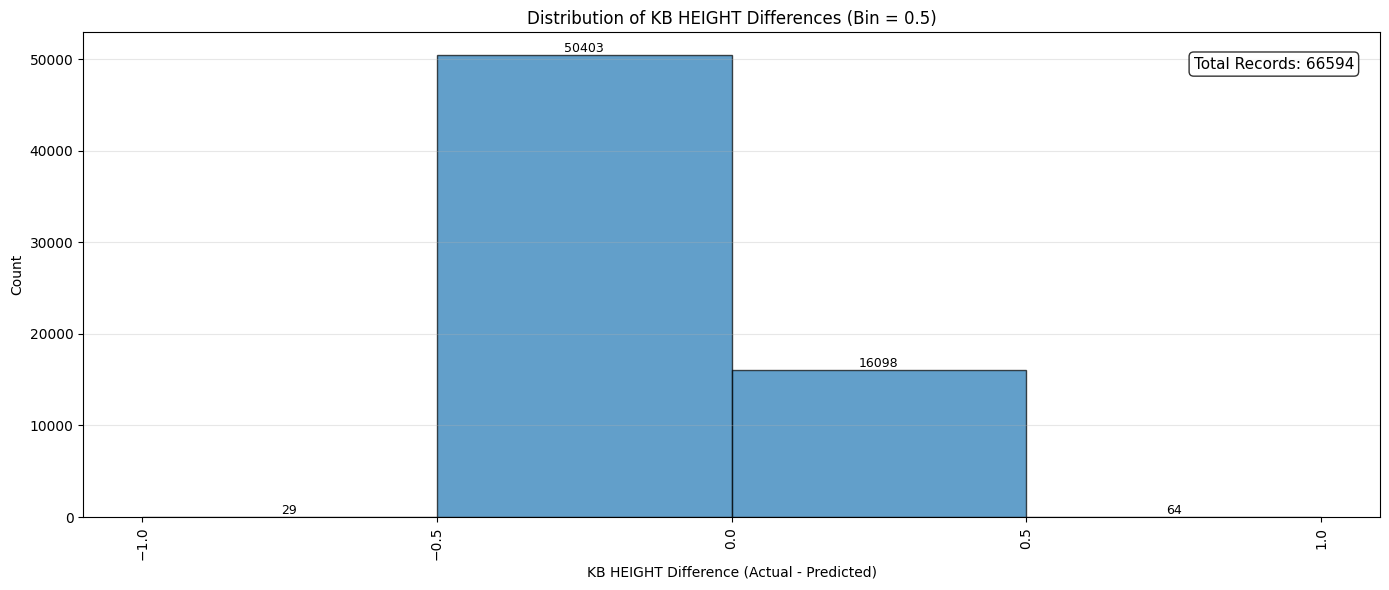

In [241]:
import matplotlib.pyplot as plt
import numpy as np

# Difference between actual and predicted
kb_height_diff = y_test - y_pred

# Bin width
bin_width = 0.5

# Create aligned bins
min_edge = bin_width * np.floor(kb_height_diff.min() / bin_width)
max_edge = bin_width * np.ceil(kb_height_diff.max() / bin_width)
bin_edges = np.arange(min_edge, max_edge + bin_width, bin_width)

plt.figure(figsize=(14, 6))

# Histogram
counts, bins, patches = plt.hist(
    kb_height_diff,
    bins=bin_edges,
    edgecolor='black',
    alpha=0.7
)

# Label counts on bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom',
            fontsize=9
        )

# Labels
plt.xlabel('KB HEIGHT Difference (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Distribution of KB HEIGHT Differences (Bin = 0.5)')

plt.xticks(bin_edges, rotation=90)
plt.grid(axis='y', alpha=0.3)

# 👉 Total record count annotation
total_records = len(kb_height_diff)
plt.text(
    0.98, 0.95,
    f'Total Records: {total_records}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()


In [242]:
import pandas as pd
import numpy as np

# Absolute error
abs_error = np.abs(y_test - y_pred)
bins = [0, 2, 4, 6, 10, np.inf]
labels = ['0-2', '2-4', '4-6', '6-10', '10+']
error_distribution = pd.cut(
    abs_error,
    bins=bins,
    labels=labels,
    right=False
)

summary_df = (
    error_distribution
    .value_counts()
    .sort_index()
    .reset_index()
)

summary_df.columns = ['Error Range', 'Count']

# Add percentage
summary_df['Percentage (%)'] = (
    summary_df['Count'] / summary_df['Count'].sum() * 100
).round(2)

summary_df


,Error Range,Count,Percentage (%)
0,0-2,66594,100.0
1,2-4,0,0.0
2,4-6,0,0.0
3,6-10,0,0.0
4,10+,0,0.0


In [159]:
import pandas as pd

# Get the indices of the test set as they relate to the original DataFrame
#test_indices = X_test.index
#df_test = df.loc[X_test.index].copy()
df_row_test = df_row.loc[X_test.index].copy()

# Retrieve the corresponding rows from the original (pre-encoding) DataFrame
# Assume initial, pre-encoding dataframe is named 'df'
merged_test = df_row_test.copy()
#merged_test = df_test.join(df_row_test, how='left', rsuffix='_dfrow')

# Add the actual and predicted KB HEIGHT values to the test rows
#original_test_rows['KB_HEIGHT_ACTUAL'] = y_test.values
#original_test_rows['KB_HEIGHT_PREDICTED'] = y_pred
merged_test['KB_HEIGHT_ACTUAL'] = y_test.values
merged_test['KB_HEIGHT_PREDICTED'] = y_pred

# Save to CSV
#original_test_rows.to_csv('kb_height_actual_vs_predicted_testset.csv', index=False)
merged_test.to_csv(
    'kb_height_actual_vs_predicted_full_testset.csv',
    index=False
)

